In [ ]:
# Core Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection and Pipelines
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing & Feature Engineering
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
from sklearn.impute import SimpleImputer

# Algorithms (Built-in to sklearn)
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics (Regression focused)
from sklearn.metrics import (
    mean_absolute_error,    # MAE
    mean_squared_error,     # MSE
    root_mean_squared_error, # RMSE 
    r2_score                # R-squared
)

# Utils
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv('../data/vehicles.csv')
df.sample(5)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
248925,7312619361,https://lasvegas.craigslist.org/ctd/d/santa-cl...,las vegas,https://lasvegas.craigslist.org,11995,2007.0,NaN,HUMMER H3,NaN,5 cylinders,...,NaN,SUV,custom,https://images.craigslist.org/00l0l_iMQOFh5CC7...,This HUMMER H3 can be yours today!If you have ...,NaN,nv,37.175631,-113.60824,2021-04-25T18:01:46-0700
139027,7310406140,https://twinfalls.craigslist.org/ctd/d/las-veg...,twin falls,https://twinfalls.craigslist.org,39995,2016.0,chevrolet,silverado 2500hd work,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00a0a_1BqIhVrlie...,2016* *Chevrolet* *Silverado* *3500* *2500* *1...,NaN,id,36.114900,-115.21610,2021-04-21T11:05:33-0600
208543,7316830465,https://saginaw.craigslist.org/ctd/d/chesaning...,saginaw-midland-baycity,https://saginaw.craigslist.org,4995,2013.0,chrysler,200,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00101_2ETqmV5280...,WE HAVE OVER 350 VEHICLES IN STOCK! View Our...,NaN,mi,43.182400,-84.11220,2021-05-04T13:55:43-0400
371486,7314900953,https://dallas.craigslist.org/ftw/ctd/d/norman...,dallas / fort worth,https://dallas.craigslist.org,17988,2014.0,chevrolet,tahoe,NaN,8 cylinders,...,NaN,NaN,NaN,https://images.craigslist.org/00c0c_kKHJhRzSrx...,CHECK OUT THIS 2014 CHEVROLET TAHOE THAT WAS J...,NaN,tx,35.199000,-97.48410,2021-04-30T12:36:31-0500
10300,7316743109,https://phoenix.craigslist.org/nph/ctd/d/phoen...,phoenix,https://phoenix.craigslist.org,23590,2018.0,mazda,mazda6 touring sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00303_7loSHJn1r9...,Carvana is the safer way to buy a car During t...,NaN,az,33.500000,-112.05000,2021-05-04T08:41:05-0700


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [4]:
# id column is not useful and it is unique for each row
# url, region_url, image_url, description are not useful, description is unique long text for each row
#VIN is unique for each car, and it has a lot of missing values, so it is not useful 
# county has 0 non-null values, so it is not useful
# dropping these immidiately
initial_drop_cols = ['id','url', 'region_url', 'image_url', 'description', 'county', 'VIN']
df.drop(columns=initial_drop_cols, inplace=True)

In [5]:
# copying the dataframe to have a backup of the original data
df_copy = df.copy()

In [76]:
df_copy.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,lat,long,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
df['region'].value_counts()

region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64

In [7]:
# region is categorical and has 404 unique values, too much for one hot encoding, so dropping
df.drop(columns=['region'], inplace=True)

In [8]:
print(df['state'].nunique())
df['state'].value_counts()

51


state
ca    50614
fl    28511
tx    22945
ny    19386
oh    17696
or    17104
mi    16900
nc    15277
wa    13861
pa    13753
wi    11398
co    11088
tn    11066
va    10732
il    10387
nj     9742
id     8961
az     8679
ia     8632
ma     8174
mn     7716
ga     7003
ok     6792
sc     6327
mt     6294
ks     6209
in     5704
ct     5188
al     4955
md     4778
nm     4425
mo     4293
ky     4149
ar     4038
ak     3474
la     3196
nv     3194
nh     2981
dc     2970
me     2966
hi     2964
vt     2513
ri     2320
sd     1302
ut     1150
wv     1052
ne     1036
ms     1016
de      949
wy      610
nd      410
Name: count, dtype: int64

In [ ]:
# state has 51 unique values, but we leave it for now, decide later

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         426880 non-null  int64  
 1   year          425675 non-null  float64
 2   manufacturer  409234 non-null  object 
 3   model         421603 non-null  object 
 4   condition     252776 non-null  object 
 5   cylinders     249202 non-null  object 
 6   fuel          423867 non-null  object 
 7   odometer      422480 non-null  float64
 8   title_status  418638 non-null  object 
 9   transmission  424324 non-null  object 
 10  drive         296313 non-null  object 
 11  size          120519 non-null  object 
 12  type          334022 non-null  object 
 13  paint_color   296677 non-null  object 
 14  state         426880 non-null  object 
 15  lat           420331 non-null  float64
 16  long          420331 non-null  float64
 17  posting_date  426812 non-null  object 
dtypes: f

In [10]:
df.sample(5)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,lat,long,posting_date
112817,2500,2005.0,chrysler,sebring convertible,excellent,NaN,gas,156000.0,clean,automatic,NaN,NaN,NaN,NaN,fl,25.989400,-80.215300,2021-05-01T07:46:10-0400
10744,14991,2015.0,honda,civic sedan lx,good,4 cylinders,gas,70544.0,clean,automatic,fwd,NaN,sedan,black,az,33.416084,-111.791486,2021-05-03T16:51:03-0700
309716,7575,2009.0,subaru,outback 2.5i limited,excellent,NaN,gas,124588.0,clean,automatic,NaN,NaN,NaN,NaN,ok,35.990872,-95.886376,2021-04-17T10:29:39-0500
307732,0,2014.0,ford,f-250sd,excellent,8 cylinders,diesel,138319.0,clean,automatic,4wd,full-size,truck,brown,ok,34.197090,-97.160560,2021-04-10T09:26:48-0500
194565,15800,2000.0,pontiac,firebird transam,excellent,8 cylinders,gas,56000.0,clean,automatic,rwd,full-size,convertible,red,mi,42.358300,-83.900000,2021-04-08T11:02:43-0400


In [11]:
# lats and longs: bigger numbers dont necessarily mean more expensive cars, so we can drop them for now, decide later if we want to use them or not
# also have about 8000 missing values
df.drop(columns=['lat', 'long'], inplace=True)

In [12]:
# making the number of cylinders an integer by removing the 'cylinders' string and converting to numeric
df['cylinders'] = df['cylinders'].str.replace('cylinders', '').str.strip()
df['cylinders'] = pd.to_numeric(df['cylinders'], errors='coerce')


In [13]:
df.describe()

,price,year,cylinders,odometer
count,4.268800e+05,425675.000000,247904.000000,4.224800e+05
mean,7.519903e+04,2011.235191,5.968685,9.804333e+04
std,1.218228e+07,9.452120,1.602962,2.138815e+05
min,0.000000e+00,1900.000000,3.000000,0.000000e+00
25%,5.900000e+03,2008.000000,4.000000,3.770400e+04
50%,1.395000e+04,2013.000000,6.000000,8.554800e+04
75%,2.648575e+04,2017.000000,8.000000,1.335425e+05
max,3.736929e+09,2022.000000,12.000000,1.000000e+07


In [ ]:
# loaded the data, 426880 rows
# condition will be filled with 'not_reported' because it has almost 45  percent missing values, and it is a categorical variable.
# cylinders will be filled with the most frequent value for that particular car brand/model. so group by model and take mode
# will use functiontransformer in my pipeline for cylinder and age to fill the missing values.
# will probably reduce the number of states by grouping them into regions, because there are 51 unique values and it is a categorical variable., about 10 regions before one hot encoding.
# will drop the original region column cuz too many unique values and it is a categorical variable.
# will calculate the age of the car using a function transformer and drop the year posted column which i will get from the date posted column.
# will input the mileage with the median/mean value based on model/brand and the age
# might add poly features for age and mileage
# will leave the price at 500k and log transform it to balance the model's attention


In [14]:
# the target range is unreasoble, between 0 and 3.7 billion dollars. filter it to 500 to 500k
df_unfiltered =df.copy()   # keeping a copy of the unfiltered data for later use if needed
df= df[(df['price']<500000) & (df['price']>500)]
print(df.shape)

(383697, 16)


In [16]:
# the posted date column has month and time which are not useful because there is no other detail time column to compare with, will extract just the year
df['year_posted'] = pd.to_datetime(df['posting_date'], errors='coerce', utc=True).dt.year
df.drop(columns=['posting_date'], inplace=True)
df.sample(5)

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,year_posted
96001,5988,2011.0,chrysler,300,excellent,NaN,gas,123545.0,clean,automatic,rwd,NaN,sedan,grey,fl,2021.0
257367,8248,2008.0,ford,edge,excellent,6.0,gas,79572.0,clean,automatic,fwd,NaN,sedan,silver,nj,2021.0
275722,8995,2008.0,honda,cr-v,excellent,NaN,gas,102395.0,clean,automatic,4wd,NaN,SUV,grey,ny,2021.0
186279,22590,2016.0,subaru,crosstrek 2.0i limited,good,NaN,other,28379.0,clean,automatic,NaN,NaN,hatchback,NaN,ma,2021.0
5977,17995,2015.0,chevrolet,impala lt v6,like new,6.0,gas,75369.0,clean,automatic,fwd,full-size,sedan,white,ak,2021.0


In [18]:
df['year_posted'] = df['year_posted'].astype('Int64')
df['year_posted'].value_counts().sort_index(ascending=False).head()

year_posted
2021    383636
Name: count, dtype: Int64

** Okay this is basically useless as a feature since it has only 1 unique value, so we will focus on timedelta ie the car's age instead of absolute time: drop both manufactured year and year posted after calculating age
- It has about 60 nans, cannot calculate age with those, so dropping it

In [19]:
# dropping nans from year_posted
df.dropna(subset=['year_posted'], inplace=True)

** Now to our target column. The statistics for it did not look very good, 
- I already dropped outrageous values for price, Now the new distribution

In [20]:
# Percentile check
print(df['price'].quantile([0.9, 0.95, 0.99, 0.999]))

0.900     38590.00
0.950     45500.00
0.990     68788.00
0.999    119641.62
Name: price, dtype: float64


In [22]:
df['price'].isnull().sum()

np.int64(0)

** Therefore we still have 99.9 percent of our data despite dropping entries with cars below 500 dollars and above 500k dollars. 
** No nan values in the target column good

In [21]:
print('high end values:', (df['price']>=300000).sum())
print('luxury cars:', ((df['price']>=100000) & (df['price']<300000)).sum())

high end values: 9
luxury cars: 620


** Handling the year column
- The age will be a very useful column so we must know when a car was manufactured, therefore dropping nan year rows
- Also dropping any entry where the manufactured date is above 2021 because the posted date is 2021 and these are supposed to be already used cars, cannt have a negative age

In [23]:
# cleaning/handling the year column
df['year'] = df['year'].astype('Int64') 
df.dropna(subset=['year'], inplace=True)
print(df['year'].value_counts().sort_index(ascending=False).head(20))

year
2022       43
2021     1645
2020    17490
2019    22318
2018    31484
2017    31306
2016    26580
2015    27058
2014    26160
2013    27422
2012    21790
2011    18586
2010    14626
2009    11447
2008    16073
2007    13970
2006    11975
2005    10105
2004     8549
2003     6830
Name: count, dtype: Int64


In [24]:
# checking how many cars are older than 1960, which is a reasonable cutoff for used cars, and we can drop the older ones
(df['year']<1960).sum()

np.int64(2298)

In [44]:
# filtering out cars with manufacturing year before 1960 and after 2021
df = df[(df['year'] >= 1960) & (df['year'] <= 2021)]

** Now exploring the manufacturer column

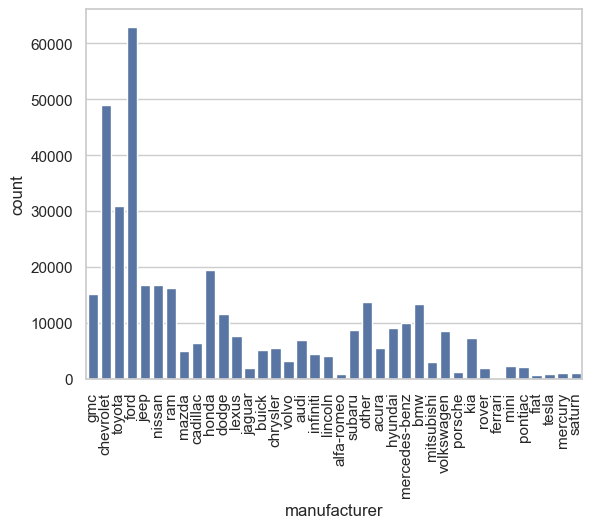

In [45]:
# plotting a bar plot for all the manufacturers
sns.countplot(data=df, x='manufacturer')
plt.xticks(rotation=90)
plt.show()

In [29]:
# looking more closely at the manufacturers
print(df['manufacturer'].nunique())
print(df['manufacturer'].isnull().sum())
print(df['manufacturer'].value_counts().head(42))

42
13727
manufacturer
ford               62979
chevrolet          48898
toyota             30878
honda              19370
nissan             16784
jeep               16737
ram                16166
gmc                15163
bmw                13304
dodge              11565
mercedes-benz      10062
hyundai             9092
subaru              8761
volkswagen          8492
lexus               7589
kia                 7274
audi                7008
cadillac            6422
acura               5551
chrysler            5499
buick               5055
mazda               4927
infiniti            4402
lincoln             3987
volvo               3246
mitsubishi          2980
mini                2214
pontiac             2153
rover               1929
jaguar              1864
porsche             1281
saturn              1057
mercury             1038
alfa-romeo           857
tesla                835
fiat                 730
harley-davidson      136
ferrari               79
datsun                59
ast

** Handling the high cardinality for manufacturer's column. 
- The harley davidson brand only produces motocycles, not cars, a few rows, so dropping
- The Nans and brands with less than 50 occurences will be grouped as 'other' to reduce cardinality
- Also land rover and rover are the same brand so grouped together

In [46]:
# dropping rows with harley-davidson manufacturer 
df = df[df['manufacturer'] != 'harley-davidson']


df['manufacturer'] = df['manufacturer'].fillna('other')

counts = df['manufacturer'].value_counts()
small_brands = counts[counts < 75].index
df['manufacturer'] = df['manufacturer'].replace(small_brands, 'other')

df['manufacturer'] = df['manufacturer'].replace('land rover', 'rover')

df['manufacturer'].nunique()


38

In [47]:
#save the df as it is now, before cleaning the model column, to have a backup of the data before cleaning the model column
df_before_model_cleaning = df.copy()

** Now exploring the model column

In [48]:
df['model'].value_counts().tail(50)

model
susburban lt 4x4                   1
f15o fx4 sport                     1
Panel Van                          1
2500 hd high country               1
fuso fec52s                        1
International DuraStar 4200        1
2010 Scion XB                      1
3200                               1
charger limo limousine             1
big horn 2016                      1
Camry Le                           1
ISUZU NPR-HD DIESEL                1
1500 flex fuel                     1
c3500hd 6.5 diesel                 1
e450 super duty cutaway            1
g3500 express hitop                1
VOLKSWAGON TIGUAN                  1
Saab 9-3 Turbo 4                   1
malibu classic ls                  1
2500 ls                            1
Thunder Creek Fuel Trailer MT2     1
1500 z71                           1
rx& gls sport                      1
ATI                                1
gand wagoneer                      1
gmce sierra                        1
Hackney Beverage body           

In [49]:
print((df['model'].value_counts() == 1).sum())

13589


In [50]:
# 1. Create the sandbox WITHOUT forcing everything to strings (keeps NaNs safe)
df['model_test'] = df['model'].str.lower()

# 2. SURGICAL FIX: Join 'f' and '150' (handles f-150, f 150 -> f150)
# We look for 'f', an optional space/dash, and then digits
df['model_test'] = df['model_test'].str.replace(r'f[- ]?(\d{3})', r'f\1', regex=True)

# 3. Fix other punctuation for the rest of the cars (Dashes/Dots -> Spaces)
# But we DON'T remove the space we just made for 'f150'
df['model_test'] = df['model_test'].str.replace(r'[-.]', ' ', regex=True)

# 4. Clean up the whitespace
df['model_test'] = df['model_test'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Check the results
print(df[df['model_test'].str.contains('f150', na=False)][['model', 'model_test']].head(10))

                           model                   model_test
31                     f-150 xlt                     f150 xlt
47   f150 super cab xl pickup 4d  f150 super cab xl pickup 4d
50        f150 supercrew cab xlt       f150 supercrew cab xlt
57    f150 regular cab xl pickup   f150 regular cab xl pickup
78   f150 super cab xl pickup 4d  f150 super cab xl pickup 4d
81         f150 supercrew cab xl        f150 supercrew cab xl
173    f150 lariat supercrew 4x4    f150 lariat supercrew 4x4
177       f150 supercrew cab xlt       f150 supercrew cab xlt
193                         f150                         f150
207                         f150                         f150


** While exploring the model column, some rows have info about the number of cylinders and so we fill the possible fillable cylinders from that bacause cylinders have about 43% missing values. The v8 or v6 or 6cyl are the number of cylinders for that row, so we search our model column and map the number of cylinders.
- 

156415


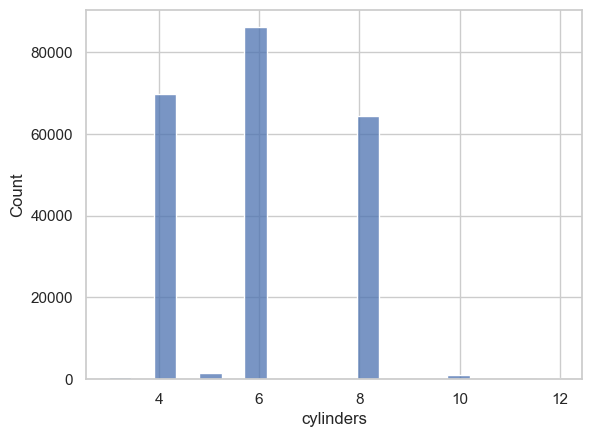

In [52]:
# checking the distribution of the cylinders column in a histogram
print(df['cylinders'].isnull().sum())
sns.histplot(data=df, x='cylinders', bins=20)
plt.show()


In [53]:
# doing the mapping with the info from the model column 

df['model_test'] = df['model_test'].str.lower()   #converting to lowercase to make the mapping easier, because the model column has a lot of variations in the way the cylinders are written, for example 'v6', 'v 6', 'v-6', '6 cyl', '6cyl', etc. and we want to catch all of these variations with our regex and mapping.


found = df['model_test'].str.extract(r'([v]\d{1,2}|\d{1,2}\s?cyl)', expand=False)  # This regex looks for either 'v' followed by 1 or 2 digits (like v6, v8) OR 1 or 2 digits followed by an optional space and 'cyl' (like 6 cyl, 6cyl). The parentheses capture the part of the string that matches, which we will use for mapping.

numeric_mapping = {                  # This mapping converts the extracted strings to numeric values for the number of cylinders.
    'v4': 4.0, '4cyl': 4.0, '4 cyl': 4.0,
    'v6': 6.0, '6cyl': 6.0, '6 cyl': 6.0,
    'v8': 8.0, '8cyl': 8.0, '8 cyl': 8.0,
    'v10': 10.0, '10cyl': 10.0, '10 cyl': 10.0
}

# You are mapping to your numeric format (6.0, 10.0)
df['cylinders'] = df['cylinders'].fillna(found.map(numeric_mapping))

In [54]:
# nuber of missing values in the cylinders column after the mapping
print(df['cylinders'].isnull().sum())

155295


In [ ]:
# just in case we have to go back to the data before filling the cylinders column, we save a copy of the dataframe
df_before_cylinder_filling = df.copy()

- About 1200 rows were filled, not bad but not much
- now, i will use the first two words of the model test column, then group it with manufacturer, and the year made and fine the mode number of cylinders for those siblings and fill the nans cylinders with that node. This is as accurate as it can get because same manufacturer on the same models in the same year would most likely have the same number of cylinders.

In [57]:
df['model_for_filling'] = df['model_test'].str.split().str[:2].str.join(' ')

df['cylinders'] = df.groupby(['manufacturer', 'model_for_filling', 'year'])['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
print(df['cylinders'].isnull().sum())

28109


In [58]:
# Now we leave the year grouping and group only by manufacturer and model for filling the remaining missing values in the cyliinders column

df['cylinders'] = df.groupby(['manufacturer', 'model_for_filling'])['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
print(df['cylinders'].isnull().sum())

12476


In [59]:
# still some nans, so i will group by the manufacturer and the first word of the model for filling the remaining missing values in the cyliinders column

df['model_1_word'] = df['model_test'].str.split().str[0]

# broader filling
df['cylinders'] = df.groupby(['manufacturer', 'model_1_word'])['cylinders'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
print(df['cylinders'].isnull().sum())

6557


In [63]:
# Cleaning up the workbench
df.drop(columns=['model_for_filling', 'model_1_word'], inplace=True)

- Cylinder nans have left about 150k to 6k. The rest might be very unique cars we couldnt group or perhaps electric cars. Let us check fuel column and see

In [60]:
df['fuel'].value_counts()

fuel
gas         318165
other        27355
diesel       25860
hybrid        4753
electric      1588
Name: count, dtype: int64

In [61]:
# electric cars have 0 cylinders, so we can fill the remaining nans in the cylinders column with 0 for the electric cars
df.loc[df['fuel'] == 'electric', 'cylinders'] = df['cylinders'].fillna(0.0)
print(df['cylinders'].isnull().sum())

6339


- justabout 200 rows were filled but electric are about 1588, filling all the electric cars with 0 cylinders.
- This likely happened because the cylinders were filled according to brand and manufacturer and electric cars have those in common with other caars.

In [62]:
# justabout 200 rows were filled but electric are about 1588, filling all the electric cars with 0 cylinders.
df.loc[df['fuel'] == 'electric', 'cylinders'] = 0.0

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380048 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         380048 non-null  int64  
 1   year          380048 non-null  Int64  
 2   manufacturer  380048 non-null  object 
 3   model         376004 non-null  object 
 4   condition     236990 non-null  object 
 5   cylinders     373709 non-null  float64
 6   fuel          377721 non-null  object 
 7   odometer      377992 non-null  float64
 8   title_status  373365 non-null  object 
 9   transmission  378309 non-null  object 
 10  drive         264904 non-null  object 
 11  size          107017 non-null  object 
 12  type          298872 non-null  object 
 13  paint_color   270228 non-null  object 
 14  state         380048 non-null  object 
 15  year_posted   380048 non-null  Int64  
 16  model_test    376004 non-null  object 
dtypes: Int64(2), float64(2), int64(1), object(12)
memory

- Now cylinder column has about 6k left of nans. will fill this with median after splitting the data later
- Back to finishing the model column, two many long strings, i will take the first word of the model column(brand) and attach with its manufacturers to differentiate between eg 3500 of different manufacturers
- Then i will use frequency to smooth out the cars that still dont fit into a major category into 'others'. Big grouping but trade off for high cardinality and the model of the car is an important column

In [65]:
df['model'] = df['manufacturer'] + ' ' + df['model_test'].str.split().str[0]
# now how many unique categories do we have in the model column after this 
print(f"Unique categories: {df['model'].nunique()}")

Unique categories: 4499


In [66]:
df['model'].value_counts().tail(50)

model
dodge 880                  1
chevrolet scottdale        1
jeep gand                  1
ford f15o                  1
other cadilllac            1
chevrolet hightop          1
other gmce                 1
other vogue                1
jeep p                     1
chevrolet impalla          1
hyundai aceent             1
other f/8oo                1
lincoln mark4              1
infiniti fx1               1
gmc zr2                    1
other a6                   1
gmc c3500hd                1
other 3200                 1
other demco                1
other sienna               1
ford f300                  1
jeep dump                  1
other work                 1
other f550                 1
other sl600                1
other 3gtu2vec5eg128071    1
other 260z                 1
ford elite                 1
lexus lx740                1
other travel               1
chevrolet susburban        1
other 2c4rc1cg0cr181348    1
other gmw                  1
other f25o                 1
other nx

In [67]:
# cannot manually fix thousands of typos 
# models that only appear once
model_counts = df['model'].value_counts()
single_models = model_counts[model_counts == 1].index

# Replace them with manufacturer + ' other'
df.loc[df['model'].isin(single_models), 'model'] = df['manufacturer'] + ' other'

In [70]:
print(df['model'].isnull().sum())
df['model'].nunique()


4056


2475

In [72]:
# FOR THOSE we dont know their model we just finally call them 'manufacturer other'
df['model'] = df['model'].fillna(df['manufacturer'] + ' other')

# Just in case some 'nan' strings were created by the earlier join
df['model'] = df['model'].str.replace(r' nan$', ' other', regex=True)

In [73]:
print(df['model'].isnull().sum())
df['model'].nunique()


0


2475

- Moved the model column from 26k+ categories to ~2400
- Will probably target encode that later on or... 

In [74]:
df.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,year_posted,model_test
27,33590,2014,gmc,gmc sierra,good,8.0,gas,57923.0,clean,other,NaN,NaN,pickup,white,al,2021,sierra 1500 crew cab slt
28,22590,2010,chevrolet,chevrolet silverado,good,8.0,gas,71229.0,clean,other,NaN,NaN,pickup,blue,al,2021,silverado 1500
29,39590,2020,chevrolet,chevrolet silverado,good,8.0,gas,19160.0,clean,other,NaN,NaN,pickup,red,al,2021,silverado 1500 crew
30,30990,2017,toyota,toyota tundra,good,8.0,gas,41124.0,clean,other,NaN,NaN,pickup,red,al,2021,tundra double cab sr
31,15000,2013,ford,ford f150,excellent,6.0,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,2021,f150 xlt


- Now the condition column which is also a strong indicator of price.
- Codition has over 40% missing values too but has countable categories and can be ordinally imputed
- Will check how it relates with odometer, if fewer mileage means better condition, then i can impute the nans in condition based on the odometer column
- cant fill based on the odometer cuz correlation seems to be around 0 and the box blot is counter intuitive on the fact that fewer miles driven means best condition
- Also we calculate the age of the car and sees if it correlates with the condition
- Age does not correlate with condition either
- Will therefore call the nans a new category 'unknown' and ordinally impute them since they have a depreciative order. unknown will be between good and excellent

143058
6


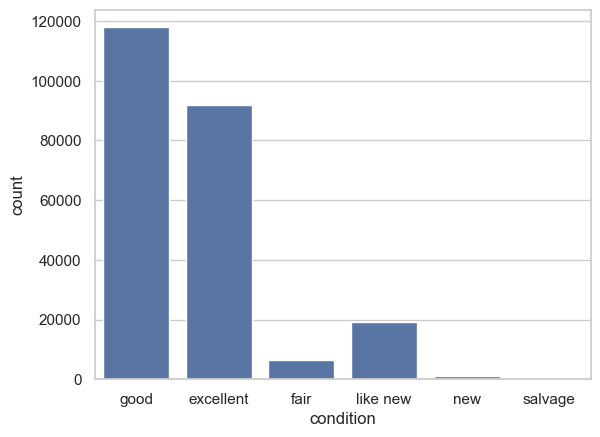

In [77]:
print(df['condition'].isnull().sum())
print(df['condition'].nunique())
sns.countplot(data=df, x='condition')
plt.show()

In [78]:
cond_map = {'new': 5, 'like new': 4, 'excellent': 3, 'good': 2, 'fair': 1, 'salvage': 0}
df['condition_num'] = df['condition'].map(cond_map)

# Correlation check
correlation = df[['condition_num', 'odometer']].corr().iloc[0, 1]
print(f"Correlation between Odometer and Condition: {correlation:.4f}")

Correlation between Odometer and Condition: -0.0134


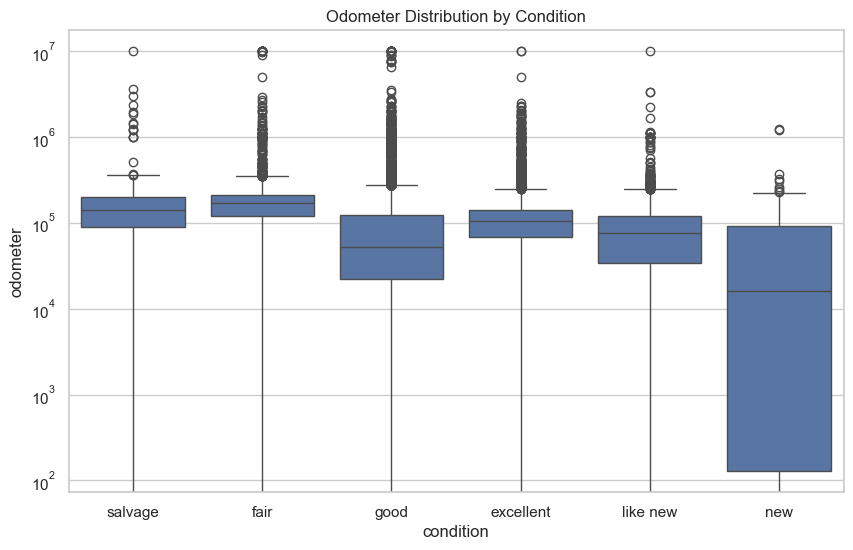

In [79]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='condition', y='odometer', order=['salvage', 'fair', 'good', 'excellent', 'like new', 'new'])
plt.yscale('log') 
plt.title('Odometer Distribution by Condition')
plt.show()

In [81]:
# Create the age column 
df['age'] = df['year_posted'] - df['year']

# Now check the correlation with our condition numbers
age_cond_corr = df[['age', 'condition_num']].corr().iloc[0, 1]
print(f"Correlation between Age and Condition: {age_cond_corr:.4f}")

Correlation between Age and Condition: -0.0320


In [82]:
# checking the new age column
print(f"Max Age: {df['age'].max()}")
print(f"Min Age: {df['age'].min()}")

Max Age: 61
Min Age: 0


In [83]:
df['condition'] = df['condition'].fillna('unknown')


# We place 'unknown' at 2.5 to keep it neutral between Good and Excellent.
condition_map = {
    'new': 5,
    'like new': 4,
    'excellent': 3,
    'unknown': 2.5, 
    'good': 2,
    'fair': 1,
    'salvage': 0
}
df['condition'] = df['condition'].map(condition_map)

print(df['condition'].value_counts())
print(f"Remaining NaNs in condition: {df['condition'].isnull().sum()}")

# drop the condition_num column now
df.drop(columns=['condition_num'], inplace=True)

condition
2.5    143058
2.0    117915
3.0     91962
4.0     19314
1.0      6329
5.0       959
0.0       511
Name: count, dtype: int64
Remaining NaNs in condition: 0


- Now checking the fuel column
- Just filling the fuel nans with 'other' category

In [84]:
print(df['fuel'].isnull().sum())
df['fuel'].value_counts()

2327


fuel
gas         318165
other        27355
diesel       25860
hybrid        4753
electric      1588
Name: count, dtype: int64

In [85]:
# Merging the NaNs into the existing 'other' category
df['fuel'] = df['fuel'].fillna('other')

# Verify the result
print(df['fuel'].isnull().sum())

0


- Now looking at the odometer column.
- Checking its range
- very few nans, will drop them, about 0.05% of the data
- will filter the 0 value rows out and impossible mileage like 500k miles out, 
- then log transform the column since it has a very lomng skewed tail

2056


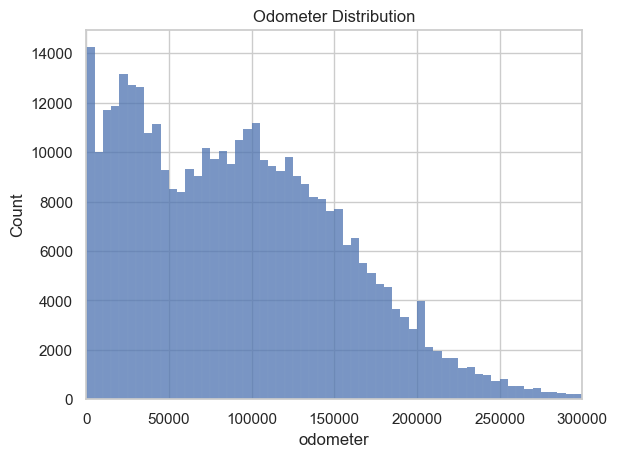

In [89]:
print(df['odometer'].isnull().sum())
# plotting a histogram for the odometer column to check the distribution and decide how to handle the missing values
sns.histplot(data=df, x='odometer', bins=2000)
plt.xlim(0, 300000)  # Focus on the range where most data points lie
plt.title('Odometer Distribution')  
plt.show()

In [102]:
df.dropna(subset=['odometer'], inplace=True)

#  Filter out the 0s and the 500k+ outliers

df = df[(df['odometer'] > 0) & (df['odometer'] < 500000)]

# Applying the Log Transform
df['odometer'] = np.log1p(df['odometer'])

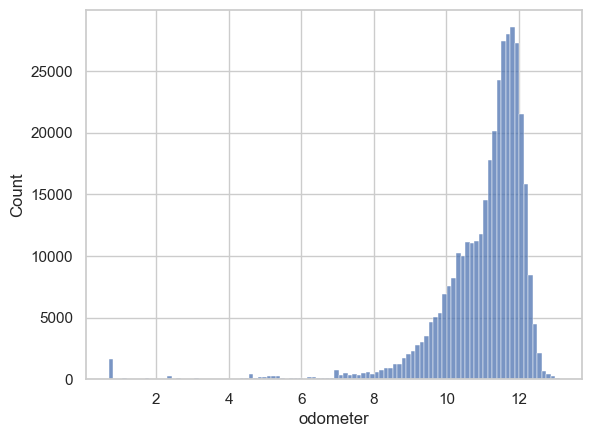

In [104]:


# plotting the histogram again after the log transform to check the distribution
sns.histplot(data=df, x='odometer', bins=100)
plt.show()

In [108]:
df.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,year_posted,age
27,33590,2014,gmc,gmc sierra,2.0,8.0,gas,10.966887,clean,other,NaN,NaN,pickup,white,al,2021,7
28,22590,2010,chevrolet,chevrolet silverado,2.0,8.0,gas,11.173669,clean,other,NaN,NaN,pickup,blue,al,2021,11
29,39590,2020,chevrolet,chevrolet silverado,2.0,8.0,gas,9.860632,clean,other,NaN,NaN,pickup,red,al,2021,1
30,30990,2017,toyota,toyota tundra,2.0,8.0,gas,10.624371,clean,other,NaN,NaN,pickup,red,al,2021,4
31,15000,2013,ford,ford f150,3.0,6.0,gas,11.759793,clean,automatic,rwd,full-size,truck,black,al,2021,8


- Now exploring the title status column.
- Has a few categories, so filling nan with 'unknown' and will onehot encode it

In [106]:
print(df['title_status'].isnull().sum())
df['title_status'].value_counts()

6227


title_status
clean         357151
rebuilt         6925
salvage         3650
lien            1397
missing          506
parts only       113
Name: count, dtype: int64

In [107]:
# forgot to drop model_test column, dropping it now
df.drop(columns=['model_test'], inplace=True)

In [109]:
df['title_status'] = df['title_status'].fillna('unknown')

- Exploring the transmission column
- Fill the nans with the 'other' category

In [110]:
print(df['transmission'].isnull().sum())
df['transmission'].value_counts()

1499


transmission
automatic    292470
other         60446
manual        21554
Name: count, dtype: int64

In [111]:
# Group the NaNs with the 'other' category
df['transmission'] = df['transmission'].fillna('other')

print(f"Remaining NaNs in transmission: {df['transmission'].isnull().sum()}")

Remaining NaNs in transmission: 0


- Now exploring the drive and size columns
- Over 71% of size is empty, big assumption to impute, will just drop, also info about it can be embedded in the model category
- imputing the drive nans with 'unknown' new category

In [112]:
# exploring drive and size columns
print(df['drive'].isnull().sum())
print(df['size'].isnull().sum())
print(df['drive'].value_counts())
print(df['size'].value_counts())

113771
269909
drive
4wd    115733
fwd     94177
rwd     52288
Name: count, dtype: int64
size
full-size      55395
mid-size       31083
compact        16797
sub-compact     2785
Name: count, dtype: int64


In [113]:
df.drop(columns=['size'], inplace=True)
df['drive'] = df['drive'].fillna('unknown')

In [114]:
df.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,year_posted,age
27,33590,2014,gmc,gmc sierra,2.0,8.0,gas,10.966887,clean,other,unknown,pickup,white,al,2021,7
28,22590,2010,chevrolet,chevrolet silverado,2.0,8.0,gas,11.173669,clean,other,unknown,pickup,blue,al,2021,11
29,39590,2020,chevrolet,chevrolet silverado,2.0,8.0,gas,9.860632,clean,other,unknown,pickup,red,al,2021,1
30,30990,2017,toyota,toyota tundra,2.0,8.0,gas,10.624371,clean,other,unknown,pickup,red,al,2021,4
31,15000,2013,ford,ford f150,3.0,6.0,gas,11.759793,clean,automatic,rwd,truck,black,al,2021,8


- Now exploring the state, type and paint_color columns
- State has no nans, good
- The type definitely influences the price. about 20% missing, already has a 'other' category so filling nans with that
- The paint colour might influence the price, fill the missing nans with new 'unknown' category

In [116]:
#- Now exploring the state, type and paint_color columns
print('NANs in state:', df['state'].isnull().sum())
print('NANs in type:', df['type'].isnull().sum())
print('NANs in paint_color:', df['paint_color'].isnull().sum())
print(df['type'].value_counts())
print(df['paint_color'].value_counts())
print(df['state'].value_counts())

NANs in state: 0
NANs in type: 79976
NANs in paint_color: 108163
type
sedan          76576
SUV            67591
pickup         40202
truck          29544
other          19397
coupe          17275
hatchback      15561
wagon           9637
van             7685
convertible     7064
mini-van        4459
offroad          569
bus              433
Name: count, dtype: int64
paint_color
white     70703
black     56792
silver    39042
blue      28518
red       27861
grey      21939
green      6673
custom     6020
brown      6018
yellow     1878
orange     1750
purple      612
Name: count, dtype: int64
state
ca    42203
fl    25469
tx    20547
ny    17418
oh    16058
mi    15843
or    12656
pa    12471
nc    12261
wa    11669
wi    10885
tn    10266
co    10116
il     9249
nj     9117
va     8564
id     7819
az     7808
ia     7672
ma     7549
mn     7099
ga     6184
ks     5856
mt     5829
sc     5517
ok     5512
in     5373
ct     4879
al     4539
md     4259
ky     3995
mo     3803
nm     3617

In [117]:
#  Filling type with 'other'
df['type'] = df['type'].fillna('other')

#  Filling paint_color with 'unknown'
df['paint_color'] = df['paint_color'].fillna('unknown')


# verifying
print(df[['type', 'paint_color', 'state', 'drive']].isnull().sum())

type           0
paint_color    0
state          0
drive          0
dtype: int64


In [122]:
# Are there still any NaNs in the dataframe?
print(df.isnull().sum().sum())

6096


In [123]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
price              0
year               0
manufacturer       0
model              0
condition          0
cylinders       6096
fuel               0
odometer           0
title_status       0
transmission       0
drive              0
type               0
paint_color        0
state              0
year_posted        0
age                0
dtype: int64


- okay missing values in the cylinder, will impute with median after splitting to avoid data leakage
- Now finalise the df to start preprocessing.
- the age is calculated from the year and year_posted, so i can drop them

In [126]:
# Dropping the redundant year columns
df.drop(columns=['year', 'year_posted'], inplace=True)

# Double check the column list
df_before_preprocessing = df.copy()  # keeping a copy of the dataframe before preprocessing for later use if needed
print(f"Remaining columns: {list(df.columns)}")

Remaining columns: ['price', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'age']


** Now preprocessing **
- Split, then impute rest of cylinder rows
- log the price due to its skewedness but remember to undo the math after predicting
- Then target encode the model column
- Maybe add some poly features for age and milleage
- Then one hot encode columns with reasonable number of categories including state. aiming for max 100 columns which is okay for ~375k rows
- Sclae numerical columns

In [128]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cyl_median = X_train['cylinders'].median()

X_train['cylinders'] = X_train['cylinders'].fillna(cyl_median)
X_test['cylinders'] = X_test['cylinders'].fillna(cyl_median)

print(f"Split and Imputation (Median: {cyl_median}) complete.")

Split and Imputation (Median: 6.0) complete.


In [129]:
# now log the target variable to balance the model's attention and reduce the impact of outliers
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [130]:
# Target encoding the model column
model_map = y_train_log.groupby(X_train['model']).mean()  #this makes the mean of the price for each model in the training set, which we will use for target encoding the model column

# Mapping to Train and Test
X_train['model_enc'] = X_train['model'].map(model_map)
X_test['model_enc'] = X_test['model'].map(model_map)

# Fill missing models in Test with the global training mean because there may be some models in the test set that are not in the training set
X_test['model_enc'] = X_test['model_enc'].fillna(y_train_log.mean())

# Dropping the original string column
X_train.drop(columns=['model'], inplace=True)
X_test.drop(columns=['model'], inplace=True)

print("Target Encoding of 'model' complete.")

Target Encoding of 'model' complete.


In [132]:
# adding polynomial features for age and odometer of degree 2
for df_set in [X_train, X_test]:
    df_set['age_sq'] = df_set['age'] ** 2
    df_set['odo_sq'] = df_set['odometer'] ** 2 
    df_set['age_odo'] = df_set['age'] * df_set['odometer']

print("Poly features created: age_sq, odo_sq, age_odo")

Poly features created: age_sq, odo_sq, age_odo


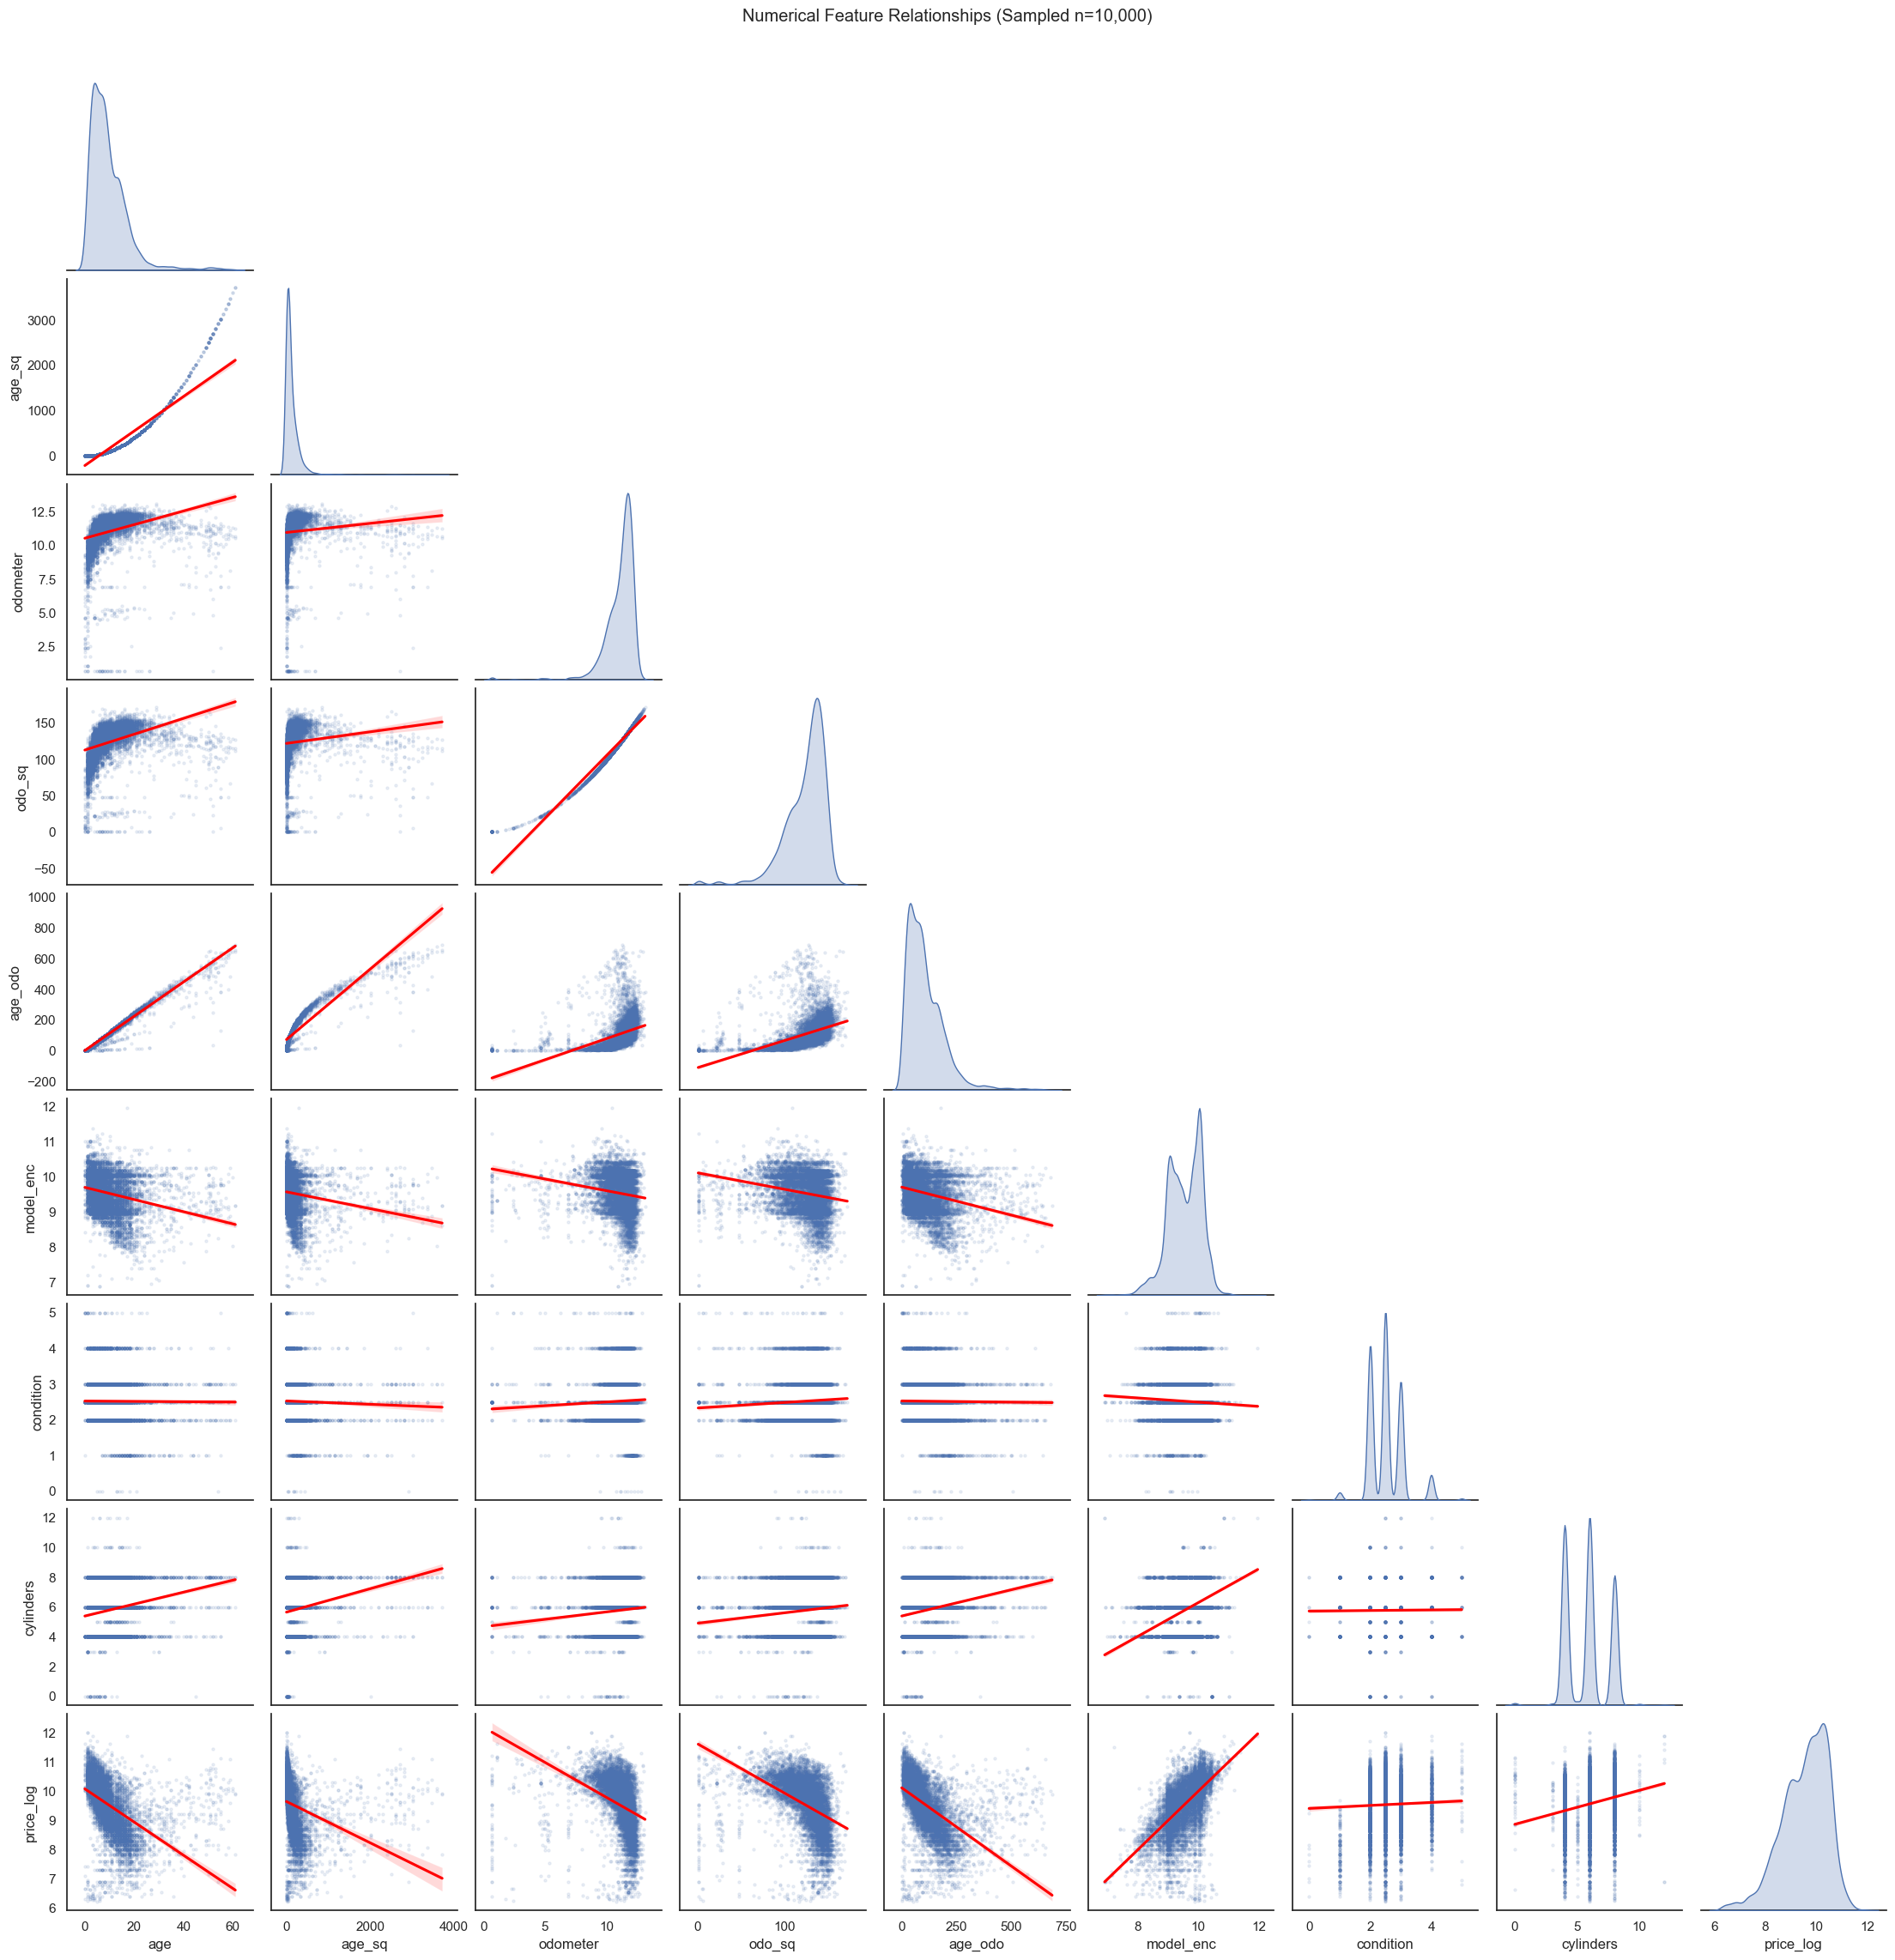

In [133]:

num_cols = ['age', 'age_sq', 'odometer', 'odo_sq', 'age_odo', 'model_enc', 'condition', 'cylinders']
temp_df = X_train[num_cols].copy()
temp_df['price_log'] = y_train_log
plot_sample = temp_df.sample(10000, random_state=42)

# Creating a Pairplot
sns.set_theme(style="white")
g = sns.pairplot(
    plot_sample, 
    diag_kind='kde', 
    kind='reg',
    corner=True, 
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1, 's': 5}}
)

g.figure.suptitle("Numerical Feature Relationships (Sampled n=10,000)", y=1.02)
plt.show()

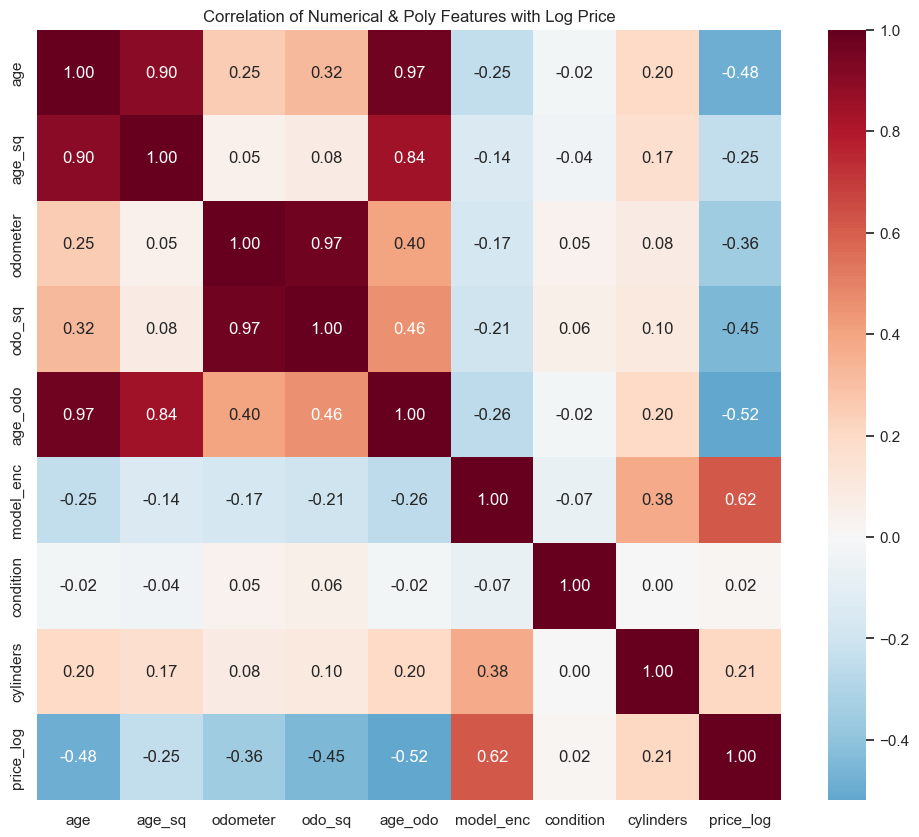

In [134]:
# correlation check for numerical features and target
plt.figure(figsize=(12, 10))
sns.heatmap(temp_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation of Numerical & Poly Features with Log Price")
plt.show()

* Age x Odometer (-0.52) is a massive win; it's way more predictive than just looking at age or miles by themselves.

* Model Target Encoding (0.62) is the absolute MVP; it's the strongest signal we've got for the "base value" of a car.

* Odometer Squared (-0.45) actually beats raw mileage, proving that value drops way faster once the miles start piling up.

* Logging the Price (-0.48) "straightened" the whole depreciation curve so the model can actually handle the math.

* Condition (0.02) is basically useless here; looks like Craigslist sellers just call everything "excellent" even when it's not.

In [135]:
# one hot encoding the categorical variables

# categorical columns to encode
cat_cols = ['manufacturer', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

# Applying One-Hot Encoding
X_train_final = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align the columns between train and test sets
X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

print(f"Final shape of X_train: {X_train_final.shape}")

Final shape of X_train: (300775, 134)


In [136]:
# Standard Scaling the numerical features
scaler = StandardScaler()

# scaling the numerical features.
num_cols_to_scale = ['age', 'age_sq', 'odometer', 'odo_sq', 'age_odo', 'model_enc', 'condition', 'cylinders']


X_train_final[num_cols_to_scale] = scaler.fit_transform(X_train_final[num_cols_to_scale])
X_test_final[num_cols_to_scale] = scaler.transform(X_test_final[num_cols_to_scale])

** Now trying some linear models 
- Based on the r2 scores, the linear model captures quite alot despte its simplicity, the std shows the models are stable regardless on which fold of the cv they are on,
- Ridge wins because of best r2 score and lower std
- The models are all similar that tuning one of these linear models wont get us much further, so we can try more powerful models

In [137]:
# 
from sklearn.linear_model import ElasticNet
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "SGD": SGDRegressor(learning_rate='adaptive', eta0=0.01, penalty='elasticnet', max_iter=2000)
}

results = {}

#  the loop
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_final, y_train_log, cv=5, scoring='r2', n_jobs=-1)
    
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    
    results[name] = mean_score
    print(f"{name}: R2 = {mean_score:.4f} ± {std_score:.4f}")

Linear: R2 = 0.7077 ± 0.0039
Ridge: R2 = 0.7077 ± 0.0038
Lasso: R2 = 0.7009 ± 0.0042
ElasticNet: R2 = 0.7041 ± 0.0040
SGD: R2 = 0.7076 ± 0.0038
